In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Spatial density function
def rho(x, y):
    R = 1 # Radius
    if x**2 + y**2 <= R**2:
        return 1.0
    else:
        return 0.1
# def rho(x, y):
#     return 1 - (x**2 + y**2) / 2  

# ###############################################
# #  Gaussian Sampling
# num_samples = 1000 # Number of samples
# mu_x, mu_y = 0.0, 0.0  # Mean for x and y
# sigma_x, sigma_y = 0.5, 0.5  # Standard deviation for x and y

# # Sample x and y from Gaussian distribution
# sampled_positions = []
# x_samples = np.random.normal(mu_x, sigma_x, num_samples)
# y_samples = np.random.normal(mu_y, sigma_y, num_samples) 
# sampled_positions = np.column_stack((x_samples, y_samples))
# #print(sampled_positions)
####################################################
# Rejection sampling for position
def rejection_sampling_positions(number_samples):
    #number_samples = 1000 # Number of samples
    sampled_positions = []
    
    # Define the domain bounds
    x_min, x_max = -1.0, 1.0
    y_min, y_max = -1.0, 1.0
    D = 4 # Area of D = [-1, 1]**2
    
    
    # Sample (x, y) uniformly from the domain D
    x = np.random.uniform(x_min, x_max, number_samples)
    y = np.random.uniform(y_min, y_max, number_samples)
    positions = np.column_stack((x, y))
    
    # Compute rho(x, y) in the domain D
    density_values = np.array([rho(x, y) for (x, y) in positions])
    p_max = np.max(density_values) # Maximum of rho(x, y)
    
    for i in range(len(density_values)):
        r = density_values[i] / p_max # Compute r(x, y) (rejection sampling)
        
        # Accept/reject based on r
        if np.random.uniform(0, 1) < r:
            sampled_positions.append(positions[i])
            
    num_samples = len(sampled_positions) # Number of samples
    return num_samples, sampled_positions
# s, t = rejection_sampling_positions(100) 
# print(s, len(t))
# # Number of samples to generate
# num_samples = 1000

# # Rejection sampling
# samples = []
# while len(samples) < num_samples:
#     # Step 1: Sample (x, y) uniformly from the domain D
#     x = np.random.uniform(x_min, x_max)
#     y = np.random.uniform(y_min, y_max)

#     # Step 2: Compute r(x, y)
#     r = p(x, y) / p_max

#     # Step 3: Accept/reject based on r(x, y)
#     if np.random.uniform(0, 1) < r:
#         samples.append([x, y])
# for i in range (num_samples):
#     # Sample uniformly 
#     x = np.random.uniform(-1 , 1)
#     y = np.random.uniform(-1 , 1)

#     # Accept/reject based on rho(x, y)
#     if np.random.uniform(0, 1) < rho(x, y):
#         sampled_positions.append([x, y])
# #print(sampled_positions)
        
# # ######################################################################
# # Create spatial grid
# x_grid = np.linspace(-1, 1, 100)
# y_grid = np.linspace(-1, 1, 100)
# X, Y = np.meshgrid(x_grid, y_grid)

# # Compute density values
# density_values = np.array([[rho(xi, yi) for xi in x_grid] for yi in y_grid])

# # Normalize densities to form probabilities
# probabilities = density_values / np.sum(density_values)

# # Sample positions based on probabilities
# num_samples = 10
# sampled_indices = np.random.choice(len(X.flatten()), size=num_samples, p=probabilities.flatten())
# sampled_positions = np.column_stack((X.flatten()[sampled_indices], Y.flatten()[sampled_indices]))
# print(sampled_positions)

In [2]:
def u_1(y):
    # return 0.0
    v_0 = 0.1
    delta = 1 / 30
    if y <= 0.5:
        return v_0 * np.tanh((y - 0.25) / delta)
    else:
        return v_0 * np.tanh((0.75 - y) / delta)

def u_2(x):
    # return 0.0
    delta = 5e-3  
    return delta * np.sin(2 * np.pi * x)
    
# def u_3(z):
#     return 0.0

# Define temperature 
# def T(x, y):
#     return 1.0
def T(x, y):
    return 1.0 + 0.001 * (x + y) 

def sample_velocities(sampled_positions):
    # Compute bulk velocity for sampled positions 2D
    bulk_velocities = np.array([[u_1(y), u_2(x)] for x, y in sampled_positions])
    #bulk_velocities = np.array([[0, 0] for x, y in sampled_positions]) 
    
    
    
    # Sample velocities for each position
    sampled_velocities = []
    for (x, y), (u_x, u_y) in zip(sampled_positions, bulk_velocities):
        mean_velocity = [u_x, u_y]
        variance = T(x, y)
        velocity_sample = np.random.normal(mean_velocity, np.sqrt(variance), size=2)
        sampled_velocities.append(velocity_sample)
    
    #sampled_velocities = np.array(sampled_velocities)
    return sampled_velocities

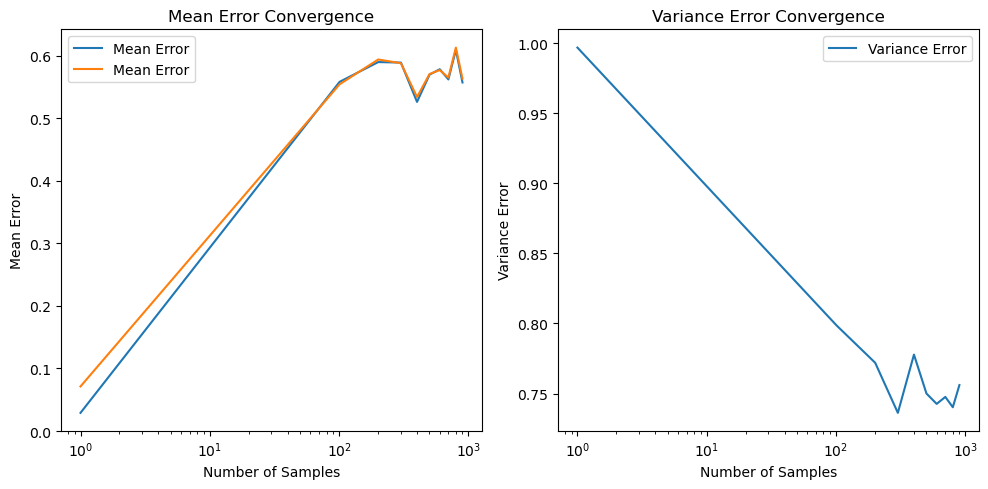

In [3]:
# Validate velocity sampling 

# Sample size
sample_sizes = np.arange(1, 1000, 100)

# Compute errors in mean and variance
def compute_error_mean_var(num_sample, sampled_positions, sampled_velocities):
    err_mean = []
    err_var = []
    for i in range(num_sample):
        x_sample, y_sample = sampled_positions[i]
        v_samples = sampled_velocities[i]

        # Compute empirical mean and variance
        empirical_mean = np.mean(v_samples, axis=0)
        empirical_variance = np.var(v_samples, axis=0)

        # Analytical values
        analytical_mean = np.array([u_1(y_sample), u_2(x_sample)])
        #analytical_mean = np.array([0, 0])
        analytical_variance = T(x_sample, y_sample)

        err_mean.append(np.abs(empirical_mean - analytical_mean))
        err_var.append(np.abs(empirical_variance - analytical_variance))
    return np.mean(err_mean, axis=0), np.mean(err_var, axis=0)
############################################
# Run the simulation for each sample size
mean_errors = []
var_errors = []
for num_samp in sample_sizes:
    num_sample, sampled_positions = rejection_sampling_positions(num_samp)
    sampled_velocities = sample_velocities(sampled_positions)
    mean_error, var_error = compute_error_mean_var(num_sample, sampled_positions, sampled_velocities)
    mean_errors.append(mean_error)
    var_errors.append(var_error)
###############################################
# Plot the results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(sample_sizes, mean_errors, label='Mean Error')
plt.xlabel('Number of Samples')
plt.ylabel('Mean Error')
plt.title('Mean Error Convergence')
plt.legend()
plt.xscale('log')

plt.subplot(1, 2, 2)
plt.plot(sample_sizes, var_errors, label='Variance Error')
plt.xlabel('Number of Samples')
plt.ylabel('Variance Error')
plt.title('Variance Error Convergence')
plt.legend()
plt.xscale('log')

plt.tight_layout()
plt.show()


(6, 6, 6, 6)


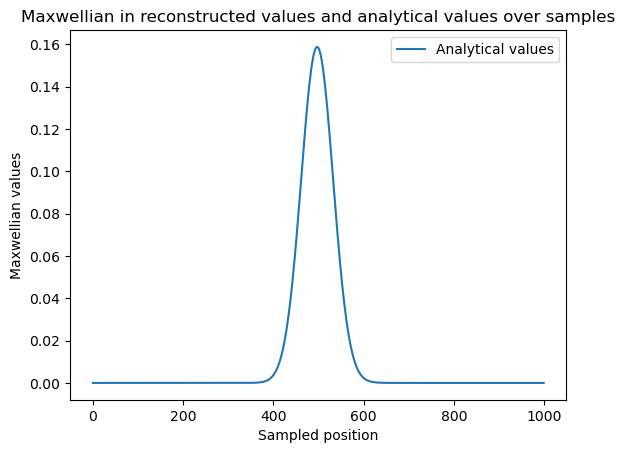

In [14]:
# Analytical Maxwellian function
def analytical_maxwellian(rho, u, T, v):
    #d_v = 2
    d_v = len(v)  # Dimensionality of velocity space
    v_arr = np.array(v)
    u_arr = np.array(u)
    return rho / ((2 * np.pi * T)**(d_v / 2)) * np.exp(-np.linalg.norm(v_arr - u_arr)**2 / (2 * T))

# Create spatial grid
x_grid = np.linspace(-1, 1, 1000)
y_grid = np.linspace(-1, 1, 1000)
v_grid_x = np.linspace(-10, 10, 1000)
v_grid_y = np.linspace(-10, 10, 1000)
#X, Y = np.meshgrid(x_grid, y_grid)
mesh_points = np.column_stack((x_grid, y_grid))
mesh_points_v = np.column_stack((v_grid_x, v_grid_y))

#Compute analytical Maxwellian values for comparison
analytical_values = [
    analytical_maxwellian(rho(x,y), u=np.array([u_1(y), u_2(x)]), T=T(x, y),  v=np.array([v_x, v_y]))
    for (x, y), v_x, v_y in zip(mesh_points, v_grid_x, v_grid_y)
]
# analytical_values = [
#     analytical_maxwellian(rho(x,y), u=[u_1(y), u_2(x)], T=T(x, y), v=velocity)
#     for (x, y), velocity in zip(sampled_positions, sampled_velocities)
# ]
# sample_velocities = sample_velocities(sampled_positions)
# print(sampled_positions)
# print(sample_velocities)
# Reconstructed Maxwellian function

#Fourier
#Spatial basis functions 
# def phi_i(x, degree=3):
#     return [1j*np.sin(2 * np.pi * i * x) for i in range(3)] + [np.cos(2 * np.pi * i * x) for i in range(degree)]

# # Velocity basis functions
# def psi_j(v, degree=3):
#     return [1j*np.sin(2 * np.pi * i * v) for i in range(3)] + [np.cos(2 * np.pi * i * v) for i in range(degree)]
# print(phi_i(1,3))

# def phi_i(x, degree=3):
#     # Scale x to the interval [-π, π]
#     t = x / np.pi  # Transform x from [-π, π] to [-1, 1]
    
#     # Generate sine functions for i from 0 to 2
#     sine_functions = [np.sin(2 * np.pi * i * t) for i in range(3)]
    
#     # Generate cosine functions for i from 0 to degree-1
#     cosine_functions = [np.cos(2 * np.pi * i * t) for i in range(degree)]
    
#     return sine_functions + cosine_functions
# def psi_j(v, degree=3):
#     # Scale x to the interval [-π, π]
#     t = v / np.pi  # Transform x from [-π, π] to [-1, 1]
    
#     # Generate sine functions for i from 0 to 2
#     sine_functions = [np.sin(2 * np.pi * i * t) for i in range(3)]
    
#     # Generate cosine functions for i from 0 to degree-1
#     cosine_functions = [np.cos(2 * np.pi * i * t) for i in range(degree)]
    
#     return sine_functions + cosine_functions    
# # Legendre
def legendre_polynomial(x, n):
    if n == 0:
        return np.ones_like(x)
    elif n == 1:
        return x
    else:
        return ((2 * n - 1) * x * legendre_polynomial(x, n - 1) - (n - 1) * legendre_polynomial(x, n - 2)) / n
# Spatial basis functions 
def phi_i(x, degree=6):
    return [legendre_polynomial(x, i) for i in range(degree)]
# Velocity basis functions
def psi_j(v, degree=6):
    return [legendre_polynomial(v, j) for j in range(degree)]

# def scaled_legendre_polynomial(v, n):
#     # Scale v to the interval [-1, 1] for Legendre polynomials
#     t = x / 2  # Transform v from [-2, 2] to [-1, 1]

#     # Normalize Legendre polynomials to make them orthonormal
#     #norm = np.sqrt(2 / (2 * n + 1))
#     norm = 1
#     if n == 0:
#         return norm * np.ones_like(t)
#     elif n == 1:
#         return norm * t
#     else:
#         return norm * ((2 * n - 1) * t * scaled_legendre_polynomial(t, n - 1) - (n - 1) * scaled_legendre_polynomial(t, n - 2)) / n    

#print(phi_i(1,3))
# def legendre_polynomial(x, n):
#     # Normalize Legendre polynomials to make them orthonormal
#     norm = np.sqrt(2 / (2 * n + 1))
#     if n == 0:
#         return norm * np.ones_like(x)
#     elif n == 1:
#         return norm * x
#     else:
#         return norm * ((2 * n - 1) * x * legendre_polynomial(x, n - 1) - (n - 1) * legendre_polynomial(x, n - 2)) / n

# # Chebyshev 
# def chebyshev_polynomial(x, n):
#     if n == 0:
#         return np.ones_like(x) 
#     elif n == 1:
#         return x
#     else:
#         return 2 * x * chebyshev_polynomial(x, n - 1) - chebyshev_polynomial(x, n - 2)
# # Spatial basis functions 
# def phi_i(x, degree=3):
#     return [chebyshev_polynomial(x, i) for i in range(degree)]
# # Velocity basis functions
# def psi_j(v, degree=3):
#     return [chebyshev_polynomial(v, j) for j in range(degree)]

num_basis_space = len(phi_i(0))  # Number of spatial basis functions
num_basis_velocity = len(psi_j(0))  # Number of velocity basis functions

# Initialize tensor C
C = np.zeros((num_basis_space, num_basis_space, num_basis_velocity, num_basis_velocity))
print(C.shape)

# Compute coefficients C_ijkl

for i in range(num_basis_space):
    for j in range(num_basis_space):
        for k in range(num_basis_velocity):
            for l in range(num_basis_velocity):
                    #for (x, y), velocity in zip(mesh_points, sample_velocities(mesh_points)):
                    for (x, y), velocity in zip(sampled_positions, sampled_velocities):
                        C[i, j, k, l] += (
                        phi_i(x)[i] *
                        phi_i(y)[j] *
                        psi_j(velocity[0])[k] *  
                        psi_j(velocity[1])[l] 
                    )

# Normalize by the number of samples
C /= num_sample


def reconstructed_maxwellian(x, y, v_x, v_y, C):
    phi_x_values = phi_i(x)
    phi_y_values = phi_i(y)
    psi_vx_values = psi_j(v_x)
    psi_vy_values = psi_j(v_y)

    result = 0
    for i in range(len(phi_x_values)):
        for j in range(len(phi_y_values)):
            for k in range(len(psi_vx_values)):
                for l in range(len(psi_vy_values)):
                        result += (
                            C[i, j, k, l] *
                            phi_x_values[i] *
                            phi_y_values[j] *
                            psi_vx_values[k] *
                            psi_vy_values[l] 
                        )
    return result

# Reconstructed values for comparison
reconstructed_values =  [reconstructed_maxwellian(x, y, v_x, v_y , C) for (x, y), v_x, v_y in zip(mesh_points, v_grid_x, v_grid_y)]
#reconstructed_values = [reconstructed_maxwellian(x, y, velocity[0], velocity[1] , C) for (x, y), velocity in zip(sampled_positions, sampled_velocities)]
resulte = [reconstructed_values[i] / analytical_values[i] for i in range(len(reconstructed_values))]
#print(resulte)
##################################
# Plot the error reconstructed_values and analytical values of Maxwellian function

fig, ax = plt.subplots()

ax.plot(reconstructed_values, label='Reconstructed values')
ax.plot(analytical_values, label='Analytical values')
ax.set_xlabel('Sampled position')
ax.set_ylabel('Maxwellian values')
ax.set_title('Maxwellian in reconstructed values and analytical values over samples')
ax.legend()
plt.show()



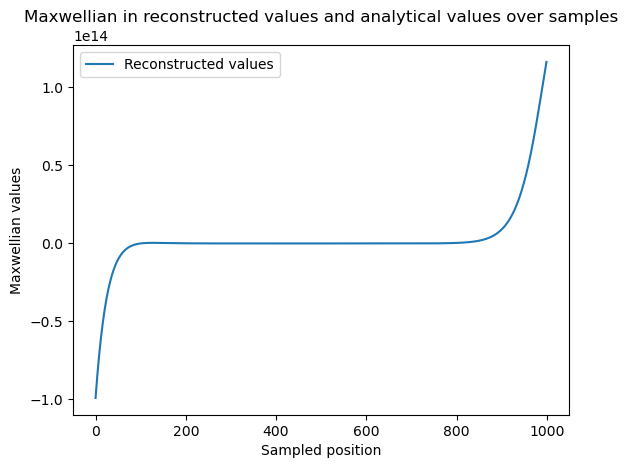

In [15]:
fig, ax = plt.subplots()

ax.plot(reconstructed_values, label='Reconstructed values')
#ax.plot(analytical_values, label='Analytical values')
ax.set_xlabel('Sampled position')
ax.set_ylabel('Maxwellian values')
ax.set_title('Maxwellian in reconstructed values and analytical values over samples')
ax.legend()
plt.show()

In [7]:
print(np.linalg.norm(2))


2.0
